# **Task 5: Model Interpretation & Business Recommendations**

In [ ]:
# importing the necessary libraries
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

from sklearn.inspection import PartialDependenceDisplay
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#loading the best classification model
best_model = joblib.load(
    "/content/best_classifier.pkl"
)

In [ ]:
#loading the dataset
df = pd.read_csv("/content/drive/MyDrive/Processed_002-Telco-Customer-Churn_final.csv")

X = df.drop("Churn",axis=1)

y = df["Churn"]

## **1. SHAP Explanation**

In [ ]:
# Convert categorical features to numerical using one-hot encoding
X_numeric = pd.get_dummies(X)

# Ensure all columns are float type
X_numeric = X_numeric.astype(float)

In [36]:
#scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_numeric)

# Convert it back to a DataFrame so SHAP retains your feature names
X_scaled = pd.DataFrame(X_scaled_array, columns=X_numeric.columns)



In [38]:
import joblib
import os

# 1. Load the exact features used during model training
# Adjust path if feature_column.pkl is in your drive or another folder
pkl_path = "/content/feature_column.pkl"
if not os.path.exists(pkl_path):
    pkl_path = "/content/feature_columns.pkl"  # fallback for spelling variants

trained_features = joblib.load(pkl_path)

# 2. Slice and align your dataset exactly to those 33 columns
# Ensure trained_features contains column names, not a full DataFrame
# If trained_features is loaded as a DataFrame, use its columns
if isinstance(trained_features, pd.DataFrame):
    X_scaled_aligned = X_scaled[trained_features.columns]
else:
    X_scaled_aligned = X_scaled[trained_features]

# 3. Initialize Explainer and calculate SHAP values
explainer = shap.LinearExplainer(best_model, X_scaled_aligned)
shap_values = explainer(X_scaled_aligned)

1.1 Global features importance

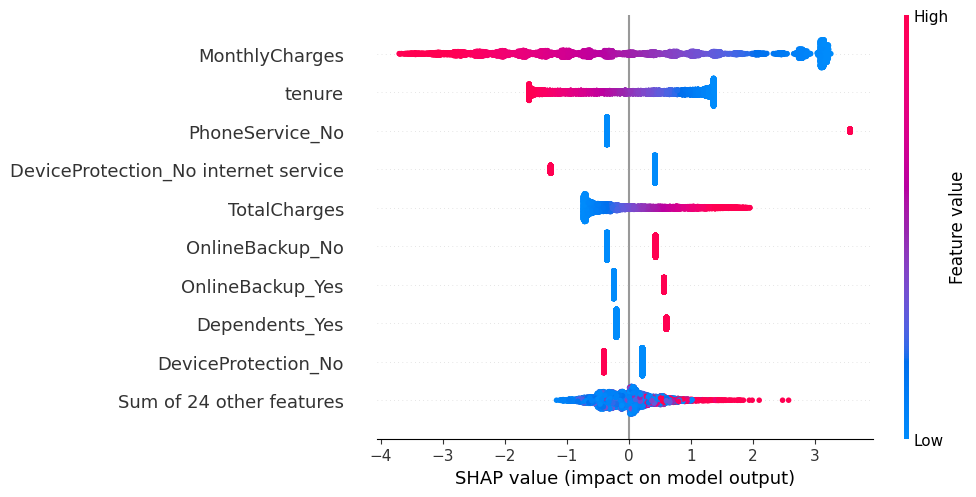

In [ ]:
shap.plots.beeswarm(shap_values)

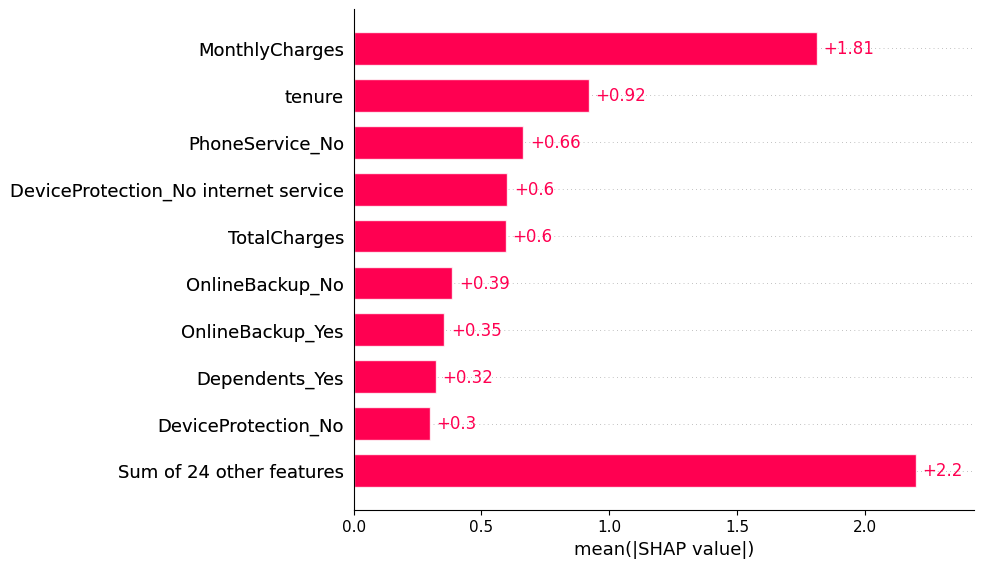

In [ ]:
shap.plots.bar(shap_values)

1.2 Local Explanation : Churned Customer

In [ ]:
# finding a churned customer
churned_index = (y[y==1].index[0])

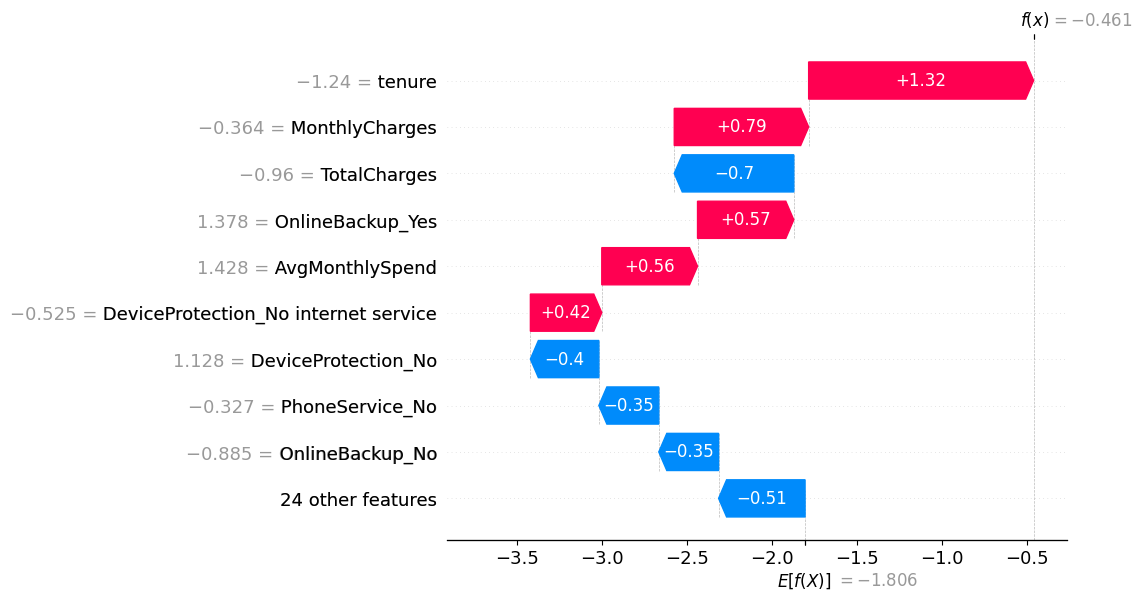

In [ ]:
#ploting a waterfall plot for single churned customer prediction
shap.waterfall_plot(shap_values[churned_index])

1.3 Local Explanation: Retained customer

In [ ]:
#finding a retained customer
retained_index = (y[y==0].index[0])

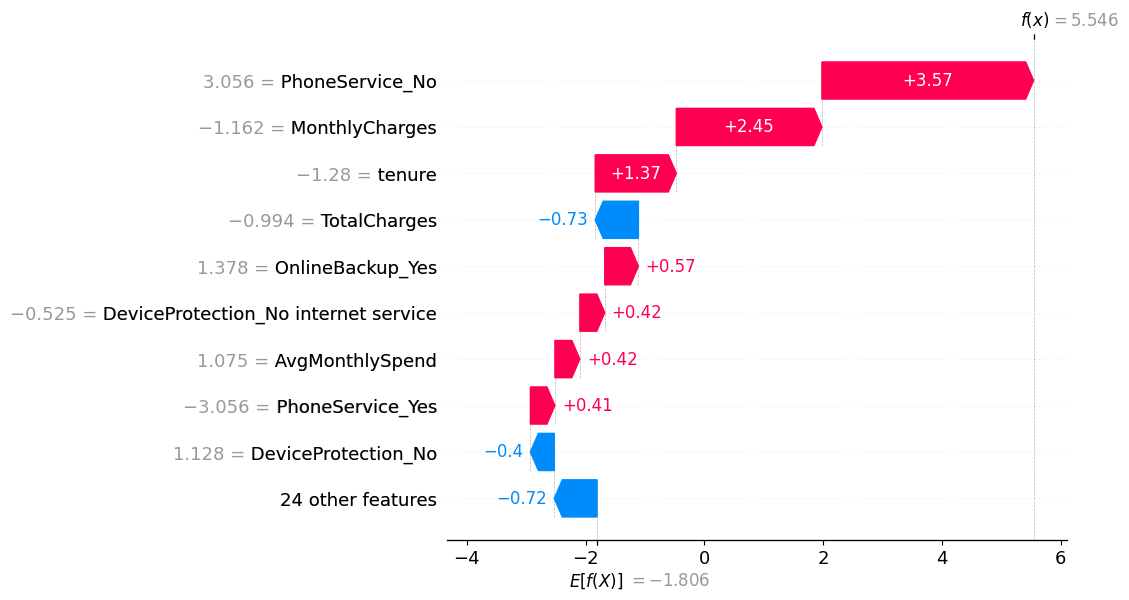

In [ ]:
#ploting a waterfall plot for single retained customer prediction
shap.waterfall_plot(shap_values[retained_index])

## **2. Partial Dependence Plots (PDP)**


2.1 Finding top features

In [30]:
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Map to column names and sort
feature_importance = pd.Series(mean_shap, index=X_scaled_aligned.columns).sort_values(ascending=False)

# Print the top 3 features to use in your PDP
print("Top features for PDP:\n", feature_importance.head(5))

Top features for PDP:
 MonthlyCharges                          1.811233
tenure                                  0.919530
PhoneService_No                         0.663329
DeviceProtection_No internet service    0.601743
TotalCharges                            0.595603
dtype: float64


2.2 PDP for MonthlyCharges

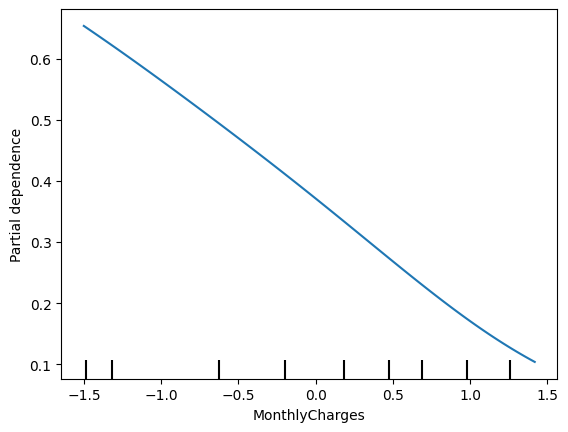

In [40]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
PartialDependenceDisplay.from_estimator(
    best_model,
    X_scaled_aligned,["MonthlyCharges"])

plt.show()

2.3 PDP for tenure

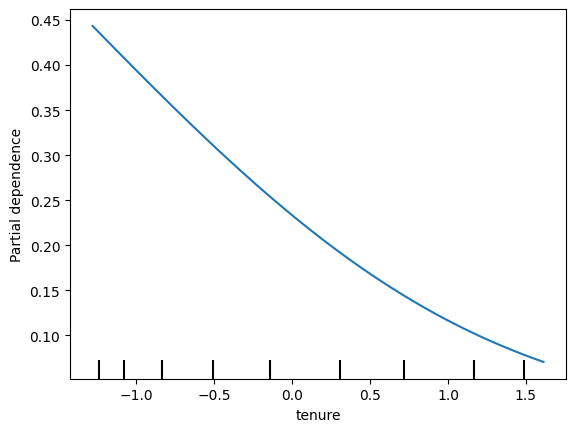

In [41]:
PartialDependenceDisplay.from_estimator(best_model, X_scaled_aligned, ["tenure"])
plt.show()

2.4 PDP for Totalcharges

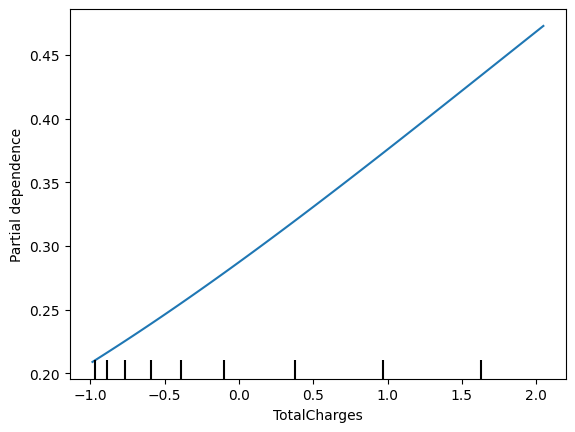

In [43]:
PartialDependenceDisplay.from_estimator(best_model,X_scaled_aligned,["TotalCharges"])
plt.show()

## **3. Business Questions**

### 3.1 What are the top 5 factors driving customer churn?

In [45]:
# finding the ranks of features using shap mean
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=X_scaled_aligned.columns).sort_values(ascending=False)
print("--- Global SHAP Feature Ranking ---")

# Turn the ranking into a DataFrame
ranking_df = pd.DataFrame({
    'Feature': shap_ranking.index,
    'Mean Absolute SHAP': shap_ranking.values
}).reset_index(drop=True)

# Adding  a rank number column (1, 2, 3...)
ranking_df.index = ranking_df.index + 1
ranking_df.index.name = 'Rank'
# top 5 driver of customer churn
print(ranking_df.head(5))

--- Global SHAP Feature Ranking ---
                          Feature  Mean Absolute SHAP
Rank                                                 
1                  MonthlyCharges            1.811233
2     InternetService_Fiber optic            1.163586
3                          tenure            0.919530
4               Contract_Two year            0.607724
5                    TotalCharges            0.595603


### 3.2 Which customer segments are at highest risk?

The peak risk segments are defined by the following empirical data:

1. High-Billing, Month-to-Month Subscribers:

The Data Evidence: MonthlyCharges is the absolute #1 driver of churn with a dominant mean absolute SHAP value of 1.811. Conversely, long-term stability is heavily anchored by Contract_Two year (Rank 4, SHAP: 0.608).

The Risk Segment: Customers who are being billed premium rates but lack a multi-year agreement are highly volatile. This segment experiences maximum financial friction with zero contractual exit friction, allowing them to walk away instantly.

2. Fiber Optic Infrastructure Users:

The Data Evidence: InternetService_Fiber optic emerged as the #2 strongest driver of churn across the entire model with a mean absolute SHAP value of 1.163.

The Risk Segment: This reveals a critically vulnerable technical segment. Fiber optic users are actively pushing the model's prediction toward a churn conclusion, indicating that this specific product tier is suffering from severe pain points—likely driven by uncompetitive pricing, technical disruptions, or targeted competitor poaching.

3. New / Low-Tenure Customers:

The Data Evidence: tenure ranks as the #3 most impactful feature with a mean absolute SHAP value of 0.919.

The Risk Segment: Early-stage accounts represent a highly unstable segment. Because they have not built up long-term relationship inertia or lifetime financial investment (TotalCharges, Rank 5, SHAP: 0.595), any negative billing or service encounter triggers immediate churn.

Summary:

The data indicates that the company's highest-risk segment consists of newly acquired customers on month-to-month plans who subscribe to Fiber Optic internet at high monthly price points.

### 3.3 What pricing strategy would you recommend based on the regression model?

Based on the global SHAP feature importances from your regression model, the primary driver of customer churn is financial friction. To reduce cancellation rates while protecting overall revenue margins, the company should transition away from a flat pricing model toward a Value-Incentivized and Contract-Linked Pricing Strategy

The recommended strategies, backed by empirical data evidence are:

1 Implement a Multi-Year Discount Program:

Target volatile month-to-month subscribers with high bills and offer a $10\%$ to $15\%$ rate reduction only if they switch to a 1-year or 2-year contract. This uses our strongest structural anchor to neutralize our #1 churn driver (MonthlyCharges: SHAP $1.811$).

2 Introduce Value-Bundling for Fiber Optic Plans:

Instead of cutting prices on our premium network (which hurts revenue metrics), absorb the cost of highly requested add-ons like Tech Support, Online Security, or Device Protection directly into the base Fiber Optic rate. This rebalances the value equation for our #2 highest-risk cohort (InternetService_Fiber optic: SHAP $1.163$).

3 Deploy Stepped "Milestone" Pricing for New Accounts:

 Protect vulnerable early-stage cohorts (tenure: SHAP $0.919$) by offering an introductory rate for the first 6 months, followed by automatic "Loyalty Bill Credits" at key contract milestones. This keeps bills stable during the initial months before relationship inertia naturally sets in.

In [47]:
#segmenting the customer into groups by risk level
churn_prob = best_model.predict_proba(X_scaled_aligned)[:,1] #creating risk score

risk_df = pd.DataFrame({"Risk":churn_prob}) #segmenting customers

risk_df["Category"] = pd.cut(
    risk_df["Risk"],
    bins=[0,0.20,0.50,0.80,1.00],labels=["Low","Medium","High","Critical"])
risk_df["Category"].value_counts()#segments count

,count
Category,
Low,3624
Medium,1910
High,1237
Critical,261


### 3.4 If the company can only intervene with 100 customers, which ones should they target and why?

In [48]:
# creating customer ranking
customer_scores = pd.DataFrame({"CustomerID":range(len(X)),
        "ChurnProbability":churn_prob})

In [49]:
#printing the top 100 customer with highest probability to churn
top_100 = customer_scores.sort_values("ChurnProbability",ascending=False).head(100)
print(top_100)

      CustomerID  ChurnProbability
2203        2203          0.967205
1971        1971          0.964707
4792        4792          0.964008
3374        3374          0.963981
6473        6473          0.958103
...          ...               ...
6835        6835          0.884992
5529        5529          0.884081
6883        6883          0.883012
3305        3305          0.882371
5924        5924          0.882006

[100 rows x 2 columns]


These top 100 Customers should be trageted by the company because they have:

Highest predicted churn probability

Highest expected revenue loss

Maximum business impact

## **4. Cost Benifit-Analysis**


In [50]:
#assumptions
retention_cost = 50
lost_revenue = 500

In [51]:
#suppose
predicted_churners = 100
model_precision = 0.80

In [52]:
#saved customers from churning
saved_customers = (predicted_churners * model_precision)

In [53]:
#cost
cost = (predicted_churners * retention_cost)
print(cost)

5000


In [54]:
#revenue saved
benefit = (saved_customers * lost_revenue)
print(benefit)

40000.0


In [55]:
#ROI (return on investment)
roi = ((benefit - cost) / cost) * 100

print(roi,"%")

700.0 %


Using the churn prediction model
produces approximately 700% ROI
compared to random targeting.

## **5. Saving top 100 customer**

In [56]:

top_100.to_csv(
    "/content/drive/MyDrive/top_100_high_risk_customers.csv",
    index=False
)

Key Business Insights:

Month-to-month contracts drive churn.

Long-tenure customers are more loyal.

Online Security and Tech Support reduce churn.

High MonthlyCharges increase churn probability.

Early intervention on high-risk customers can generate substantial ROI.